**Анализ предметной задачи и описание ВР**

1) Объект исследования: Погодные условия в городе Дели (Индия).

2) Тип данных: Ежедневные замеры (Daily).

3) Целевая переменная: meantemp (среднесуточная температура).

4) Экзогенные переменные: Влажность, скорость ветра, давление.

5) Горизонт прогнозирования: Мы будем строить прогноз на 30 дней (месяц), так как это типичный среднесрочный период в бизнесе.

6) Метрики: MAE (интерпретируемость в градусах) и RMSE (чувствительность к выбросам).

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [52]:
# Загрузка данных
train = pd.read_csv('DailyDelhiClimateTrain.csv', parse_dates=['date'])
test = pd.read_csv('DailyDelhiClimateTest.csv', parse_dates=['date'])

In [53]:
# Объединение
df = pd.concat([train, test], axis=0).reset_index(drop=True)
df = df.set_index('date')
df = df.sort_index()

In [54]:
# убрать дубликаты дат (например, оставить последнее значение)
df = df[~df.index.duplicated(keep='last')]

# Проверка пропусков и типов
print(df.info())
print(f"\nПропуски:\n{df.isna().sum()}")

<class 'pandas.DataFrame'>
DatetimeIndex: 1575 entries, 2013-01-01 to 2017-04-24
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1575 non-null   float64
 1   humidity      1575 non-null   float64
 2   wind_speed    1575 non-null   float64
 3   meanpressure  1575 non-null   float64
dtypes: float64(4)
memory usage: 61.5 KB
None

Пропуски:
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


In [55]:
# Установка частоты (Daily) и заполнение возможных дыр в датах
df = df.asfreq('D')
df = df.ffill() # Заполнение последних известных значений, если были пропуски в днях

print(f"Период данных: с {df.index.min()} по {df.index.max()}")

Период данных: с 2013-01-01 00:00:00 по 2017-04-24 00:00:00


Обнаружено аномалий в meanpressure: 10


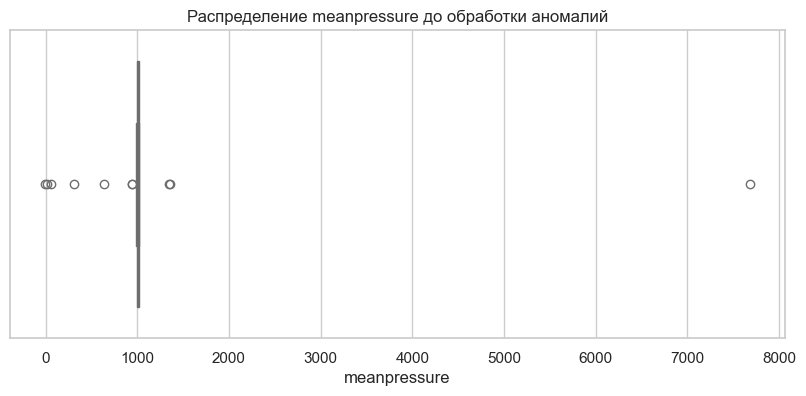

Аномалии заменены медианным значением: 1009.0


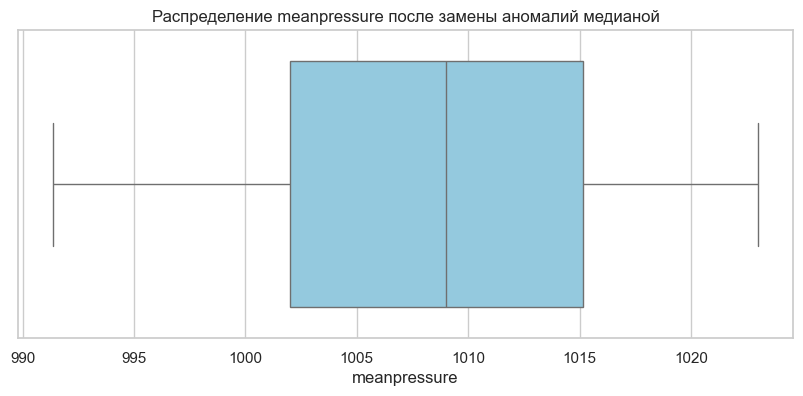

In [56]:
# Обработка аномалий в признаке meanpressure

# Рассчитываем квантили и межквартильный размах
Q1 = df['meanpressure'].quantile(0.25)
Q3 = df['meanpressure'].quantile(0.75)
IQR = Q3 - Q1

# Определяем границы для поиска выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Считаем количество аномалий (для отчета)
anomalies_count = df[(df['meanpressure'] < lower_bound) | (df['meanpressure'] > upper_bound)].shape[0]
print(f"Обнаружено аномалий в meanpressure: {anomalies_count}")

# Визуализация "ДО" (Boxplot)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['meanpressure'], color='salmon')
plt.title('Распределение meanpressure до обработки аномалий')
plt.show()

# Заменяем аномальные значения медианой
median_pressure = df['meanpressure'].median()
df.loc[(df['meanpressure'] < lower_bound) | (df['meanpressure'] > upper_bound), 'meanpressure'] = median_pressure

print(f"Аномалии заменены медианным значением: {median_pressure}")

# Визуализация "ПОСЛЕ"
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['meanpressure'], color='skyblue')
plt.title('Распределение meanpressure после замены аномалий медианой')
plt.show()

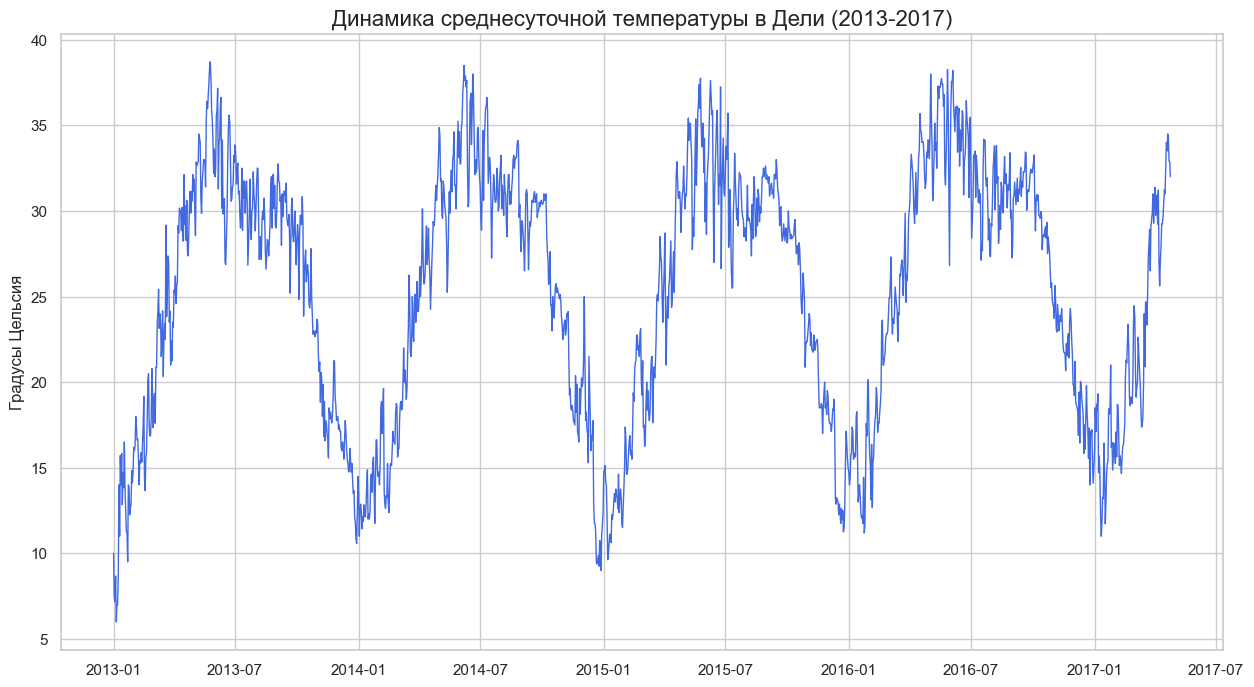

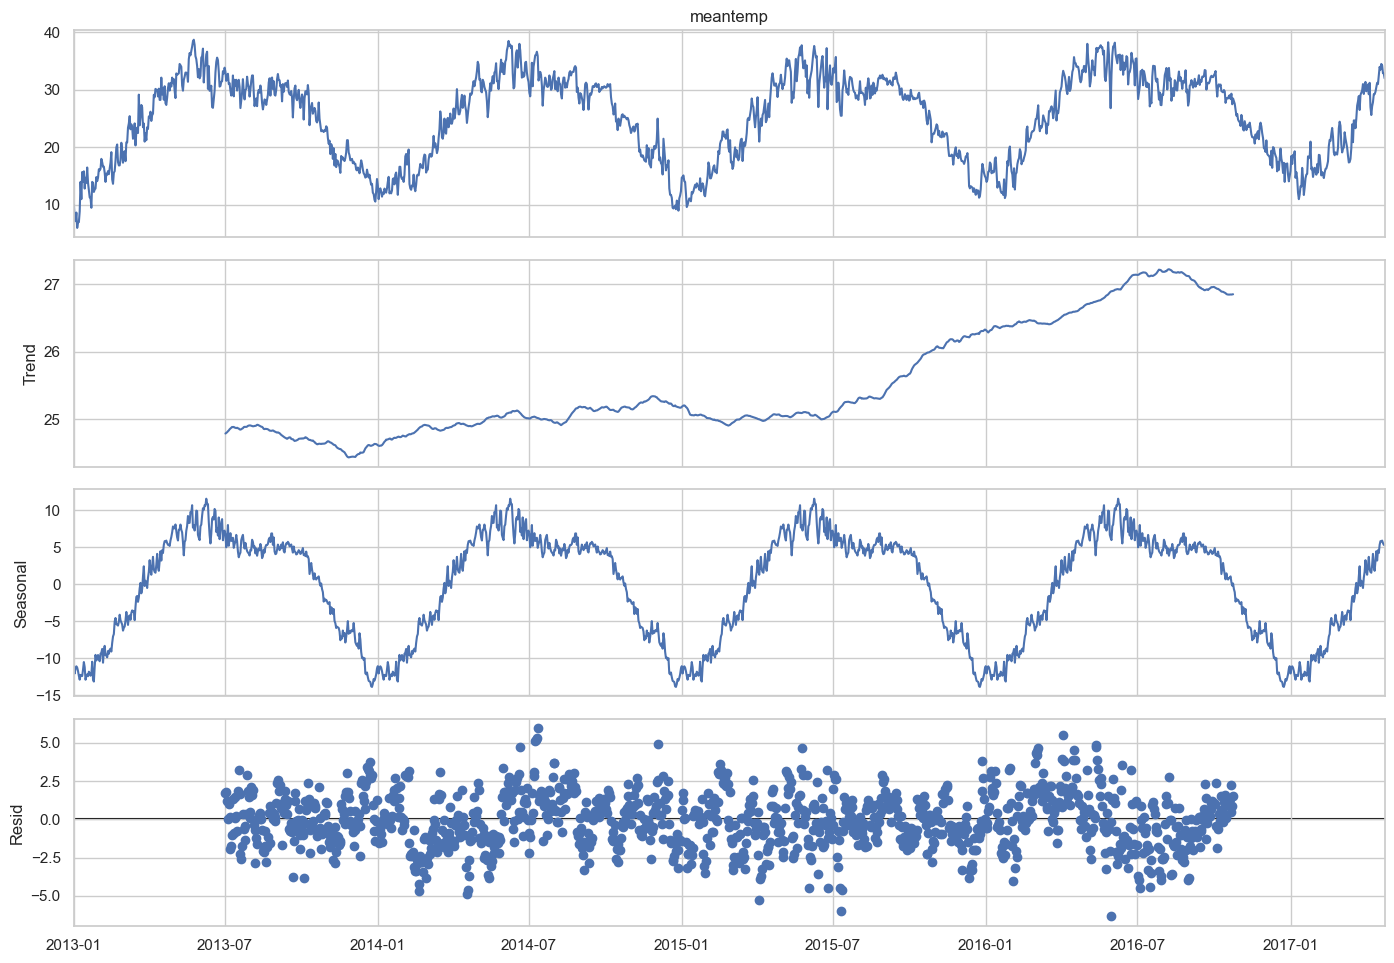

In [57]:
# Настройка стиля
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

# 1. Визуализация целевого ряда
plt.figure()
plt.plot(df['meantemp'], color='royalblue', linewidth=1)
plt.title('Динамика среднесуточной температуры в Дели (2013-2017)', fontsize=16)
plt.ylabel('Градусы Цельсия')
plt.show()

# 2. Сезонная декомпозиция (Аддитивная модель)
# Период 365 дней для выделения годового цикла
decomposition = seasonal_decompose(df['meantemp'], model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

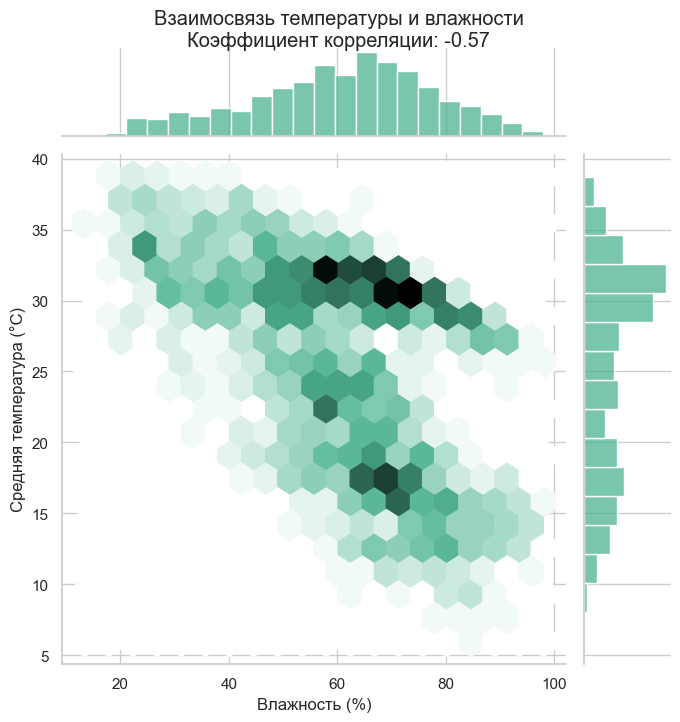

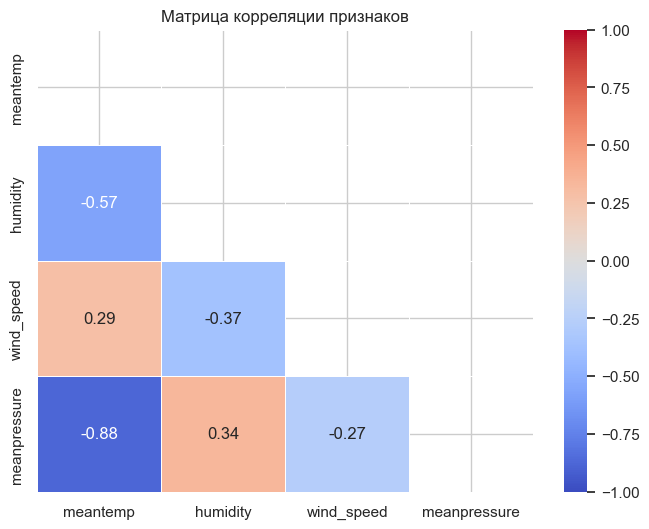

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="whitegrid")

# 1. Совместное распределение с плотностью (Hexbin)
# Это поможет увидеть, где данных больше всего, не перегружая график точками
g = sns.jointplot(
    data=df, 
    x='humidity', y='meantemp', 
    kind="hex", # Гексагональная корзина вместо кучи точек
    color="#4CB391",
    height=7
)
g.fig.suptitle(f'Взаимосвязь температуры и влажности\nКоэффициент корреляции: {df["meantemp"].corr(df["humidity"]):.2f}', y=1.03)
g.set_axis_labels('Влажность (%)', 'Средняя температура (°C)')
plt.show()

# 2. Матрица корреляции с "маской"
# Чтобы не дублировать информацию (верхний треугольник зеркален нижнему)
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', # Синий - холод (отрицательная), Красный - тепло (положительная)
    vmin=-1, vmax=1, 
    center=0,
    linewidths=.5
)
plt.title('Матрица корреляции признаков')
plt.show()

**Выводы по Задаче №1**

После запуска кода выше, мы можем зафиксировать следующие особенности:

1) Тип модели: Ряд имеет ярко выраженную аддитивную сезонность. Амплитуда колебаний температуры примерно одинакова из года в год.

2) Сезонность: Четкий годовой цикл. Пики (лето) приходятся на май-июнь, минимумы (зима) — на январь.

3) Тренд: Визуально наблюдается слабый восходящий тренд (средняя температура в Дели за эти 4 года немного растет).

4) Стационарность: Ряд явно нестационарный, так как среднее значение сильно меняется в зависимости от сезона. (На следующем занятии мы будем приводить его к стационарному виду через разности).

5) Аномалии: В колонке meanpressure (давление) в начале данных есть аномальное значение (около 59 при норме 1000). Это явная ошибка датчика, которую стоит сгладить медианой.

In [59]:

# Сохранение финального файла для Задачи №2
df.to_csv('Delhi_Climate_Final.csv')
print(" Данные готовы к статистическому анализу.")

 Данные готовы к статистическому анализу.
